PROBLEM STATEMENT:

---


In the healthcare domain, selecting the most effective drug for a patient is a critical task that depends on various physiological factors. As a beginner in machine learning, this problem focuses on building a predictive model that can assist in recommending the appropriate drug type for a patient based on their medical attributes.

In [7]:
#Import required libraries

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

1.LOAD DATASET


In [8]:
#Load the drug detection dataset
df = pd.read_csv('/content/drug200.csv')

In [9]:
tf = df.copy()


In [10]:
#Basic info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [11]:
#Statistical summary
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


2.Label Encoding(Categorical-NUmeric)

In [12]:
tf.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [13]:
# Encode all object columns using LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

Categorical columns: ['Sex', 'BP', 'Cholesterol', 'Drug']


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


3.Visualizations

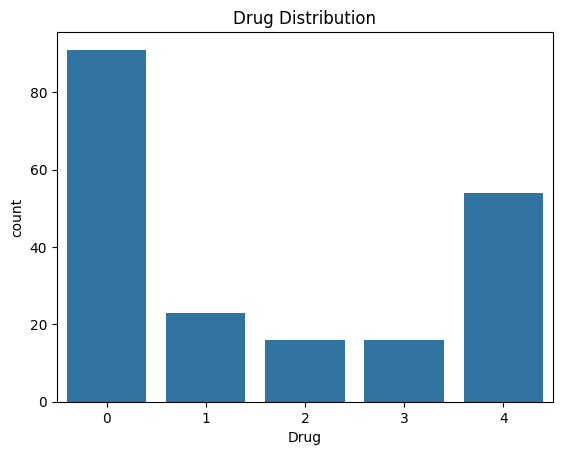

In [14]:
# Drug distribution
sns.countplot(x='Drug', data=df)
plt.title("Drug Distribution")
plt.show()

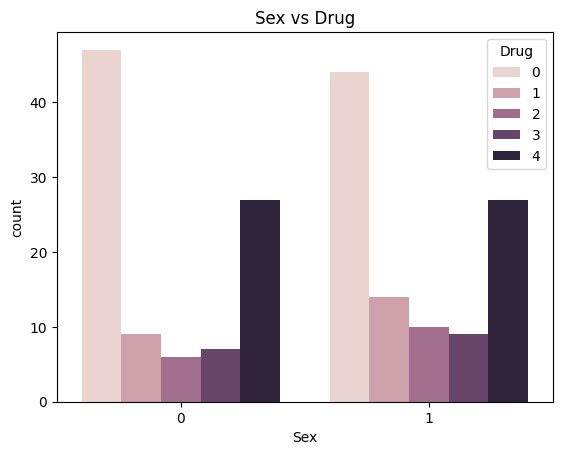

In [17]:
#Sex vs Drug
sns.countplot(x='Sex', hue='Drug', data=df)
plt.title("Sex vs Drug")
plt.show()

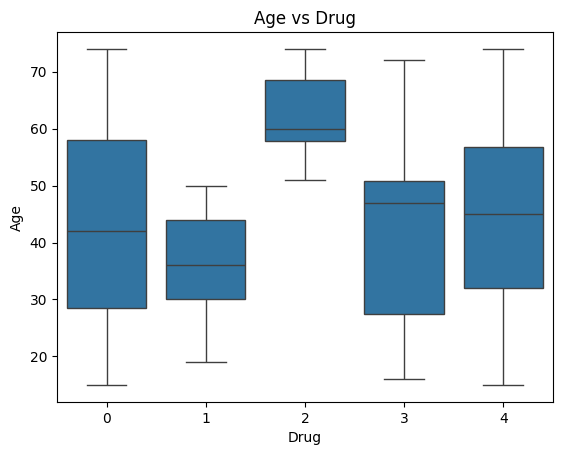

In [15]:
#Age vs Drug
sns.boxplot(x='Drug', y='Age', data=df)
plt.title("Age vs Drug")
plt.show()

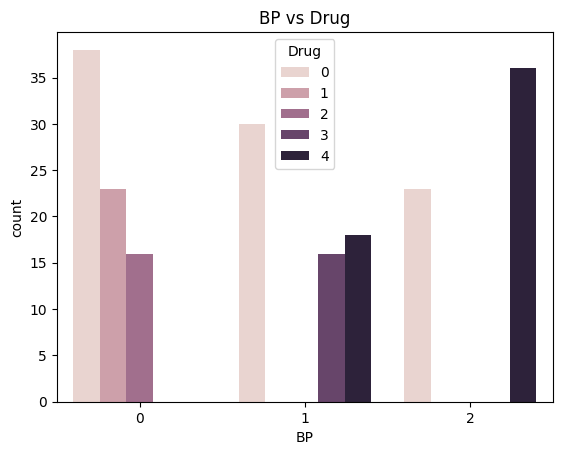

In [19]:
#Bp vs Drug
sns.countplot(x='BP', hue='Drug', data=df)
plt.title("BP vs Drug")
plt.show()


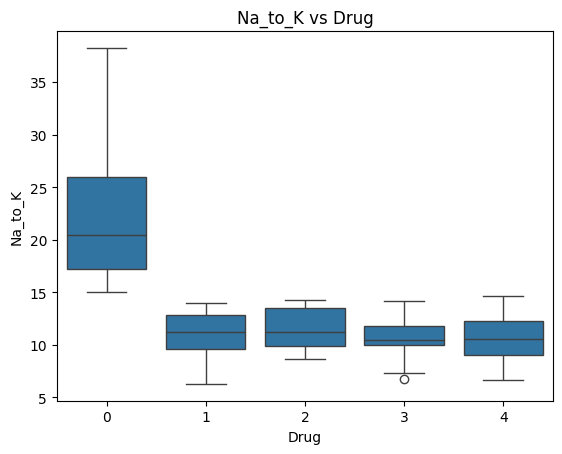

In [16]:
#Na_to_K vs Drug
sns.boxplot(x='Drug', y='Na_to_K', data=df)
plt.title("Na_to_K vs Drug")
plt.show()


4.Model Training-Logistic Regression

In [20]:
# Define features (X) and target (y)
X = df.drop(columns=['Drug'])
y = df['Drug']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (160, 5)
Test size : (40, 5)


In [21]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

5.Model Evaluation

In [22]:
# Predictions on test set
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')



Accuracy: 0.9750


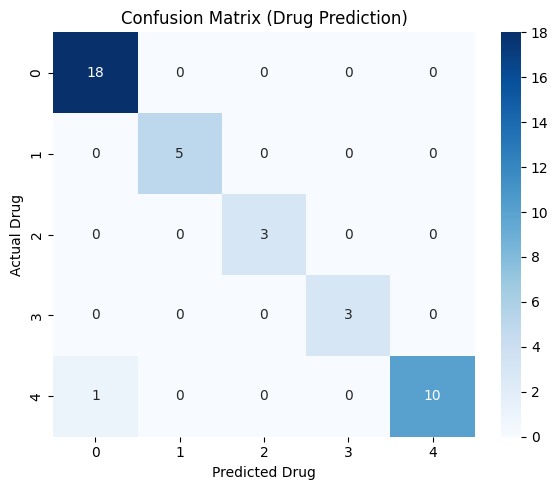

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix (Drug Prediction)')
plt.xlabel('Predicted Drug')
plt.ylabel('Actual Drug')
plt.tight_layout()
plt.show()